In [2]:
!unrar x /content/autonomous_driving.rar /content/


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/autonomous_driving.rar

Creating    /content/autonomous_driving                               OK
Extracting  /content/autonomous_driving/config.py                          3%  OK 
Extracting  /content/autonomous_driving/data_generator.py                 18%  OK 
Extracting  /content/autonomous_driving/evaluate.py                       27%  OK 
Extracting  /content/autonomous_driving/main.py                           33%  OK 
Creating    /content/autonomous_driving/models                        OK
Extracting  /content/autonomous_driving/models/pilotnet.py                38%  OK 
Extracting  /content/autonomous_driving/models/__init__.py                39%  OK 
Extracting  /content/autonomous_driving/README.md                         49%  OK 
Extracting  /content/autonomous_driving/requirements.txt                  50%

解压完成后，您可以使用 `!ls /content/` 命令查看解压后的文件。

In [1]:
!pip install -q opencv-python matplotlib tensorflow

# 验证依赖
import tensorflow as tf
import cv2
import matplotlib
print("✅ 所有依赖安装成功")
print(f"TensorFlow: {tf.__version__}")
print(f"OpenCV: {cv2.__version__}")

✅ 所有依赖安装成功
TensorFlow: 2.20.0
OpenCV: 4.13.0


In [3]:
%cd /content/autonomous_driving
!python main.py generate

/content/autonomous_driving
生成训练数据...
  样本数: 30000
  生成进度: 3000/30000
  生成进度: 6000/30000
  生成进度: 9000/30000
  生成进度: 12000/30000
  生成进度: 15000/30000
  生成进度: 18000/30000
  生成进度: 21000/30000
  生成进度: 24000/30000
  生成进度: 27000/30000
  生成进度: 30000/30000
  已保存 30000 个样本到 /content/autonomous_driving/data/train

生成验证数据...
  样本数: 5000
  生成进度: 500/5000
  生成进度: 1000/5000
  生成进度: 1500/5000
  生成进度: 2000/5000
  生成进度: 2500/5000
  生成进度: 3000/5000
  生成进度: 3500/5000
  生成进度: 4000/5000
  生成进度: 4500/5000
  生成进度: 5000/5000
  已保存 5000 个样本到 /content/autonomous_driving/data/val

生成测试数据...
  样本数: 5000
  生成进度: 500/5000
  生成进度: 1000/5000
  生成进度: 1500/5000
  生成进度: 2000/5000
  生成进度: 2500/5000
  生成进度: 3000/5000
  生成进度: 3500/5000
  生成进度: 4000/5000
  生成进度: 4500/5000
  生成进度: 5000/5000
  已保存 5000 个样本到 /content/autonomous_driving/data/test

全部数据生成完成!
  训练集: /content/autonomous_driving/data/train
  验证集: /content/autonomous_driving/data/val
  测试集: /content/autonomous_driving/data/test


In [9]:
%cd /content/autonomous_driving
!python main.py train --model smallnet --max_samples 8000

/content/autonomous_driving
自动驾驶模型训练
使用策略: _DefaultDistributionStrategy

[1/5] 加载数据...
  限制训练样本数: 30000 → 8000 (内存优化)
  训练集: 8000 样本
  验证集: 5000 样本
  图像尺寸: (80, 160, 3)

[2/5] 构建模型...
2026-07-10 13:59:52.822719: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1783691992.824202    6650 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
Model: "SmallNet"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ camera_input (InputLayer)       │ (None, 80, 160, 3)     │             0 │
├─────────────────────────────────┼──────────────────

In [5]:
!nvidia-smi

Fri Jul 10 13:48:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----


### smallnet_20260710_135953_evaluation.png


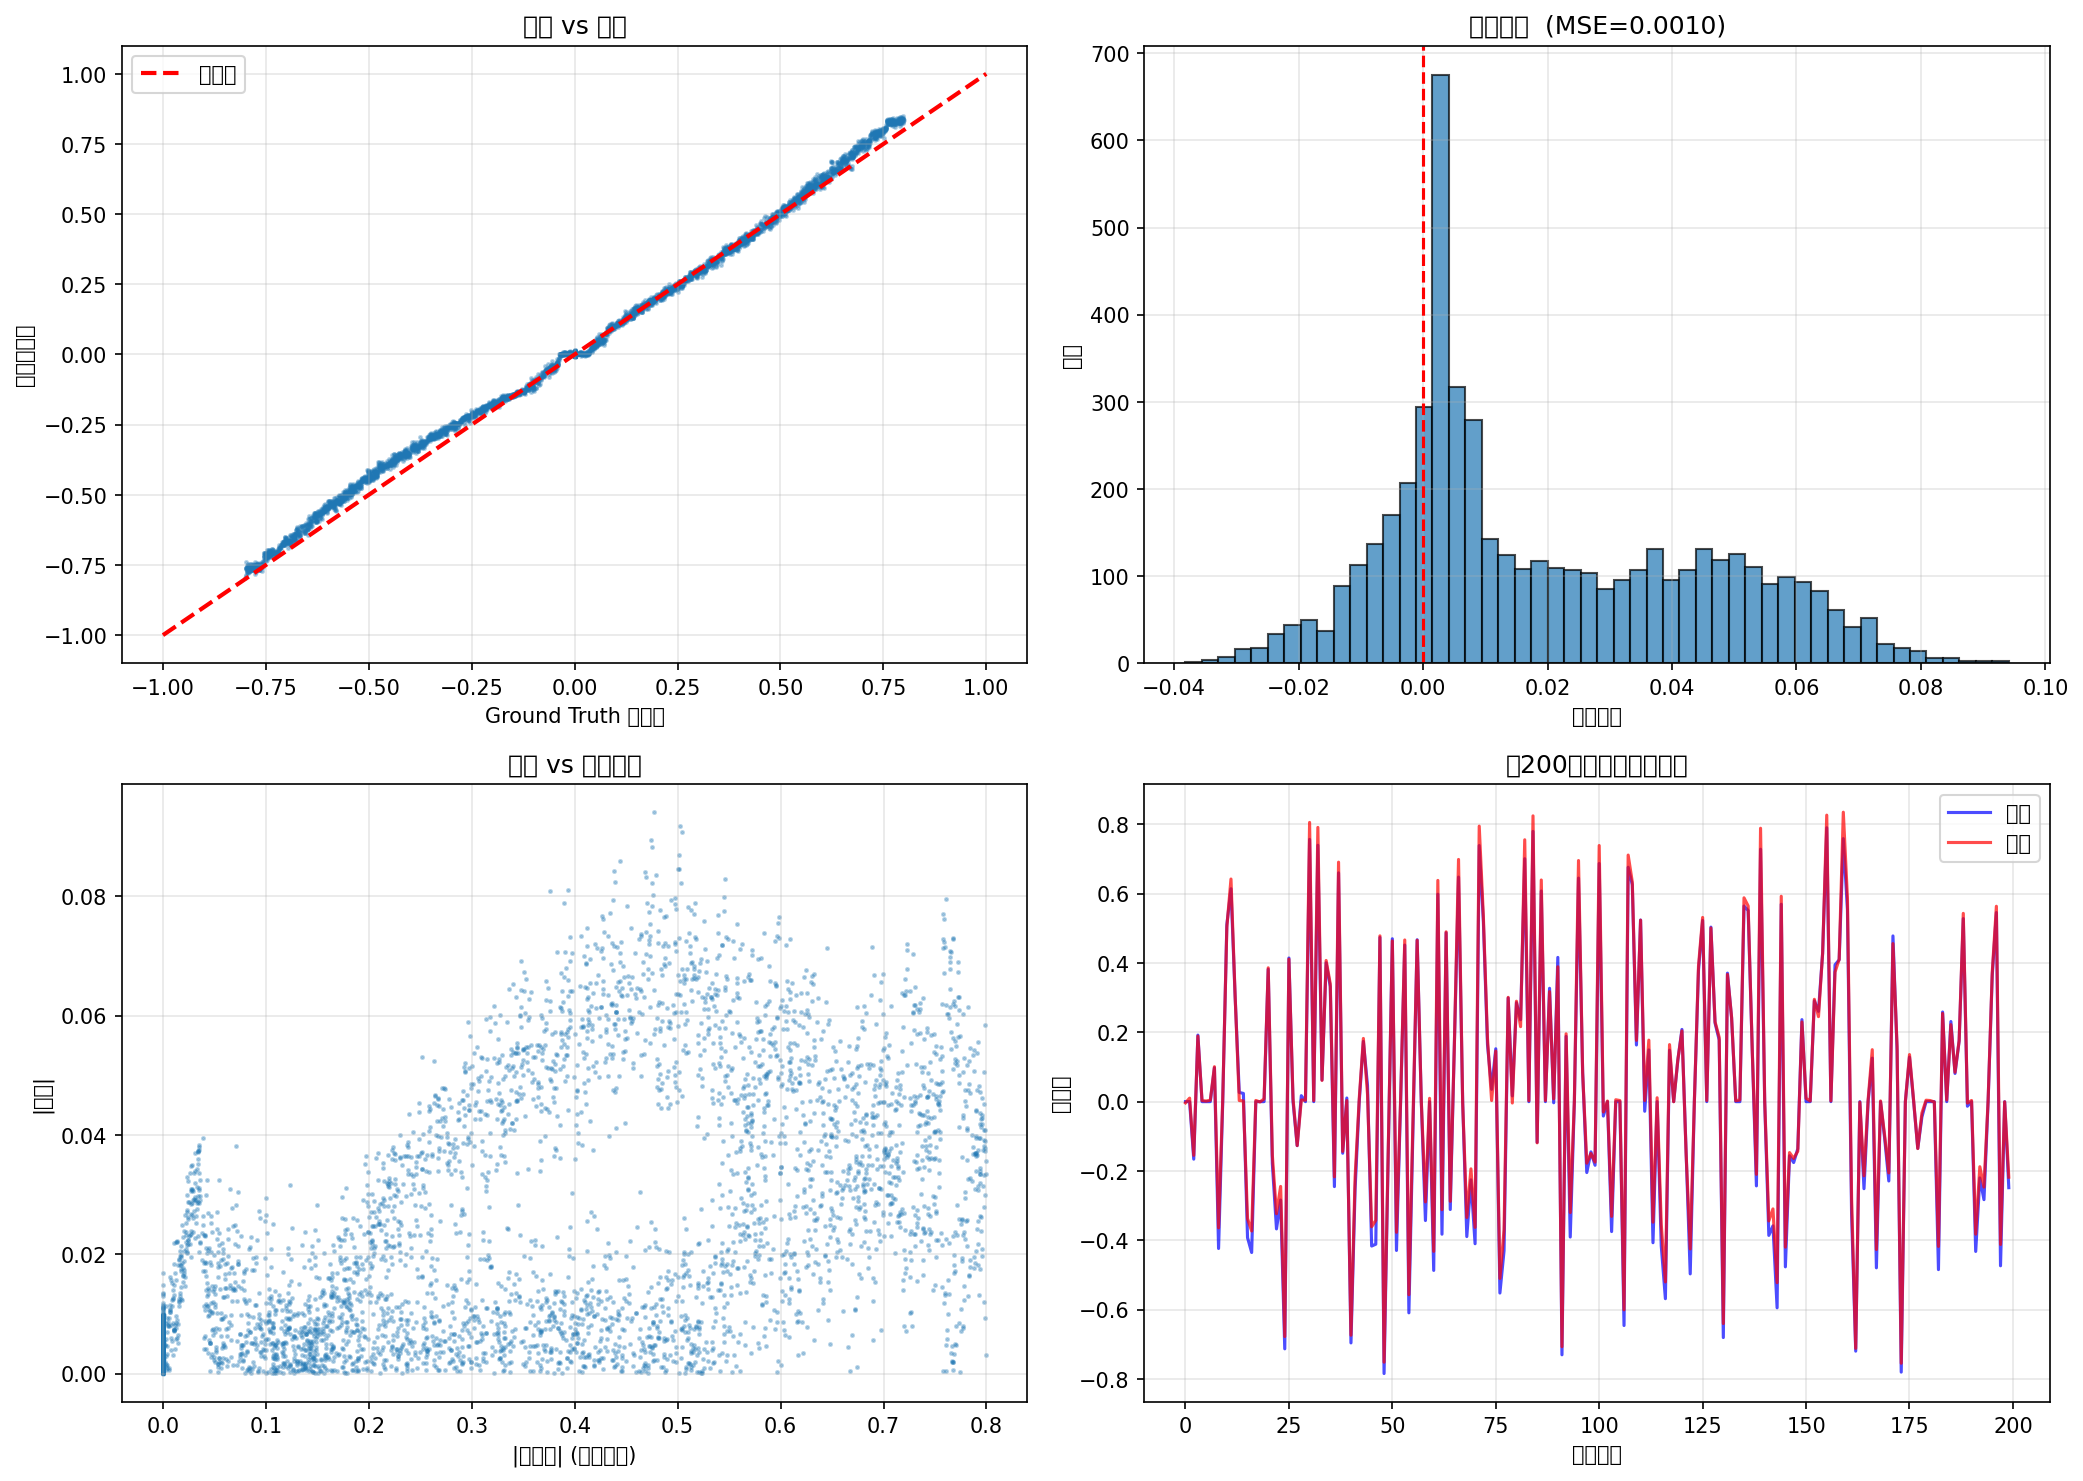


### smallnet_20260710_135953_simulation.png


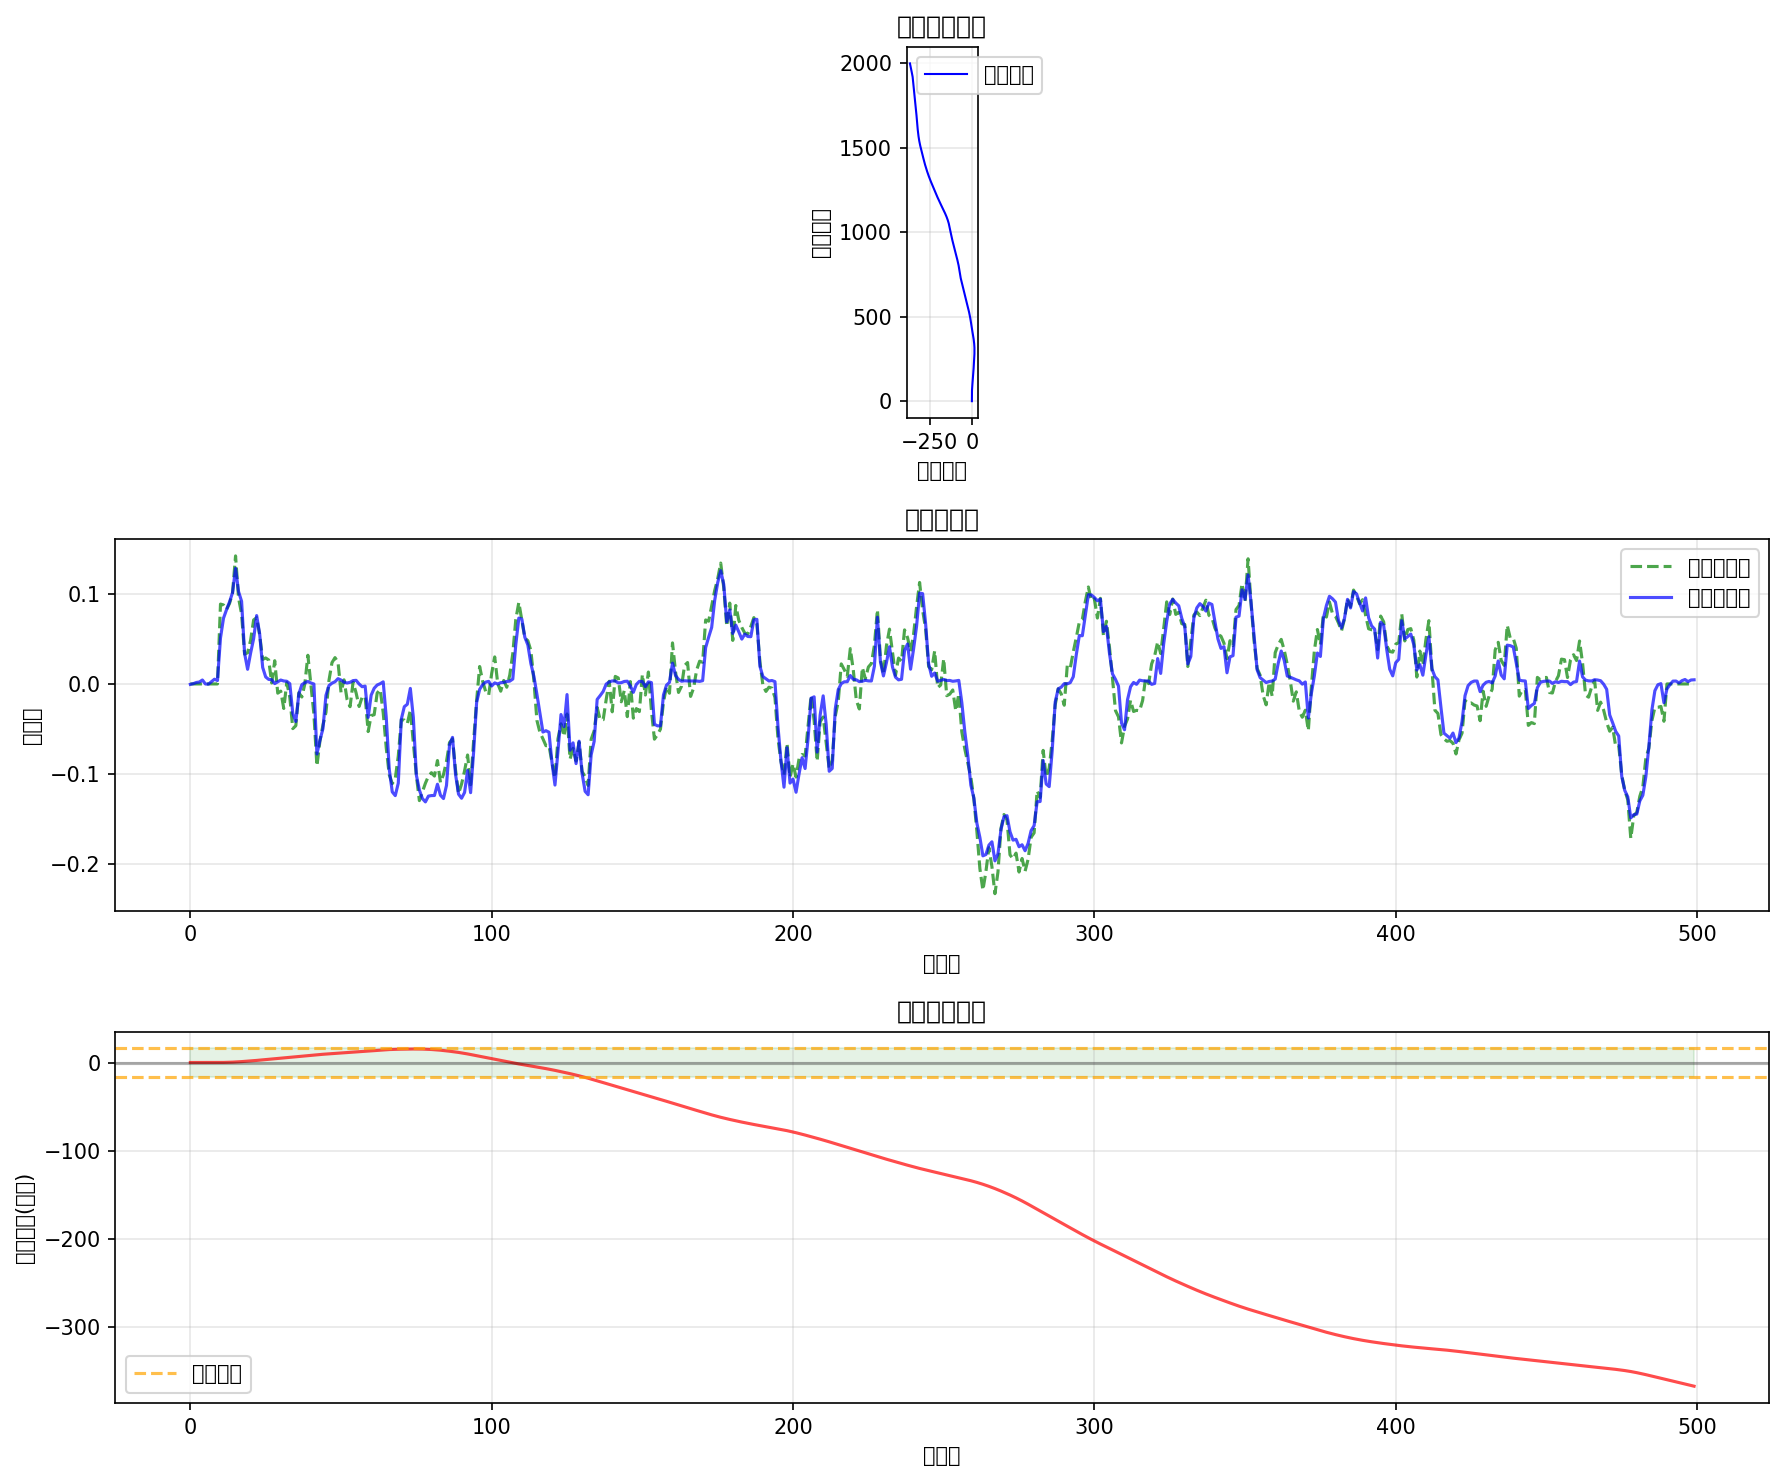

In [10]:
from IPython.display import Image, display
import os
output_dir = "output"
images = [f for f in os.listdir(output_dir) if f.endswith(".png")]
images.sort()
for img_name in images:
    print(f"\n### {img_name}")
    display(Image(filename=f"{output_dir}/{img_name}"))


In [20]:
%cd /content/sample_data/autonomous_driving
!python main.py demo

/content/sample_data/autonomous_driving
/content/sample_data/autonomous_driving/main.py:100: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/sample_data/autonomous_driving/main.py:100: UserWarning: Glyph 24613 (\N{CJK UNIFIED IDEOGRAPH-6025}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/sample_data/autonomous_driving/main.py:100: UserWarning: Glyph 24367 (\N{CJK UNIFIED IDEOGRAPH-5F2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/sample_data/autonomous_driving/main.py:100: UserWarning: Glyph 32531 (\N{CJK UNIFIED IDEOGRAPH-7F13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/sample_data/autonomous_driving/main.py:100: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/sample_data/autonomous_driving/main.py:100: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from font(s

In [11]:
!python main.py demo

/content/autonomous_driving/main.py:101: UserWarning: Glyph 24038 (\N{CJK UNIFIED IDEOGRAPH-5DE6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/autonomous_driving/main.py:101: UserWarning: Glyph 24613 (\N{CJK UNIFIED IDEOGRAPH-6025}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/autonomous_driving/main.py:101: UserWarning: Glyph 24367 (\N{CJK UNIFIED IDEOGRAPH-5F2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/autonomous_driving/main.py:101: UserWarning: Glyph 32531 (\N{CJK UNIFIED IDEOGRAPH-7F13}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/autonomous_driving/main.py:101: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/autonomous_driving/main.py:101: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/autonomous_driving/main.py:101: UserWarning: Glyph 21491 (\N{CJK UN

In [12]:
%cd /content/autonomous_driving

/content/autonomous_driving


In [13]:
!python main.py preview --weights models/checkpoints/smallnet_20260710_135953/best.weights.h5 --mode scene --frames 8

驾驶决策预览
2026-07-10 14:12:16.088875: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1783692736.090352   14214 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
已加载权重: models/checkpoints/smallnet_20260710_135953/best.weights.h5
I0000 00:00:1783692738.620805   14259 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/content/autonomous_driving/preview.py:141: UserWarning: Glyp

111
